### Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:.4f}".format)

### Load the datasets

In [2]:
BASE = Path("../data/clean")

DAILY_PATH    = BASE / "daily_adjusted" / "ALL_daily_adjusted_clean.parquet"
INCOME_PATH   = BASE / "fundamentals" / "ALL_income_statement_clean.parquet"
BALANCE_PATH  = BASE / "fundamentals" / "ALL_balance_sheet_clean.parquet"
CASHFLOW_PATH = BASE / "fundamentals" / "ALL_cash_flow_clean.parquet"
OVERVIEW_PATH = BASE / "fundamentals" / "ALL_overview_clean.csv"
OPTIONS_PATH  = BASE / "options" / "ALL_options_clean.parquet"

print(DAILY_PATH)
print(INCOME_PATH)
print(BALANCE_PATH)
print(CASHFLOW_PATH)
print(OVERVIEW_PATH)
print(OPTIONS_PATH)

../data/clean/daily_adjusted/ALL_daily_adjusted_clean.parquet
../data/clean/fundamentals/ALL_income_statement_clean.parquet
../data/clean/fundamentals/ALL_balance_sheet_clean.parquet
../data/clean/fundamentals/ALL_cash_flow_clean.parquet
../data/clean/fundamentals/ALL_overview_clean.csv
../data/clean/options/ALL_options_clean.parquet


In [3]:
# Load the datasets
daily = pd.read_parquet(DAILY_PATH)
income = pd.read_parquet(INCOME_PATH)
balance = pd.read_parquet(BALANCE_PATH)
cashflow = pd.read_parquet(CASHFLOW_PATH)
overview = pd.read_csv(OVERVIEW_PATH)
options = pd.read_parquet(OPTIONS_PATH)

print("daily:", daily.shape)
print("income:", income.shape)
print("balance:", balance.shape)
print("cashflow:", cashflow.shape)
print("overview:", overview.shape)
print("options:", options.shape)

daily: (52486, 10)
income: (781, 22)
balance: (773, 33)
cashflow: (778, 17)
overview: (10, 55)
options: (3192217, 20)


In [4]:
# Parse date columns
daily["date"] = pd.to_datetime(daily["date"])

income["fiscalDateEnding"] = pd.to_datetime(income["fiscalDateEnding"])
balance["fiscalDateEnding"] = pd.to_datetime(balance["fiscalDateEnding"])
cashflow["fiscalDateEnding"] = pd.to_datetime(cashflow["fiscalDateEnding"])

print("Dates parsed.")

Dates parsed.


In [5]:
income.head()

,symbol,fiscalDateEnding,reportedCurrency,grossProfit,totalRevenue,costOfRevenue,costofGoodsAndServicesSold,operatingIncome,sellingGeneralAndAdministrative,researchAndDevelopment,operatingExpenses,netInterestIncome,interestIncome,interestExpense,otherNonOperatingIncome,depreciationAndAmortization,incomeBeforeTax,incomeTaxExpense,netIncomeFromContinuingOperations,ebit,ebitda,netIncome
0,AAPL,2005-12-31,USD,1564000000.0000,5749000000,4185000000,4185000000,750000000.0000,632000000.0000,182000000.0000,814000000.0000,348000000.0000,1358000000.0000,81000000.0000,60000000.0000,52000000.0000,831000000.0000,266000000.0000,0.0000,750000000.0000,802000000.0000,565000000.0000
1,AAPL,2006-03-31,USD,1297000000.0000,4359000000,3062000000,3062000000,529000000.0000,592000000.0000,176000000.0000,768000000.0000,348000000.0000,1358000000.0000,76000000.0000,60000000.0000,50000000.0000,605000000.0000,195000000.0000,0.0000,529000000.0000,579000000.0000,410000000.0000
2,AAPL,2006-06-30,USD,1325000000.0000,4370000000,3045000000,3045000000,566000000.0000,584000000.0000,175000000.0000,759000000.0000,348000000.0000,1358000000.0000,0.0000,60000000.0000,57000000.0000,661000000.0000,189000000.0000,0.0000,566000000.0000,623000000.0000,472000000.0000
3,AAPL,2006-09-30,USD,1412000000.0000,4370000000,3425000000,3425000000,608000000.0000,584000000.0000,179000000.0000,804000000.0000,348000000.0000,1358000000.0000,252000000.0000,60000000.0000,66000000.0000,721000000.0000,179000000.0000,0.0000,661000000.0000,718000000.0000,542000000.0000
4,AAPL,2006-12-31,USD,2220000000.0000,7115000000,4895000000,4895000000,1322000000.0000,714000000.0000,184000000.0000,898000000.0000,348000000.0000,1358000000.0000,126000000.0000,60000000.0000,74000000.0000,1448000000.0000,444000000.0000,0.0000,1322000000.0000,1396000000.0000,1004000000.0000


In [6]:
# Inspect columns before merging
print("DAILY COLUMNS")
print(daily.columns.tolist())

print("\nINCOME COLUMNS")
print(income.columns.tolist())

print("\nBALANCE COLUMNS")
print(balance.columns.tolist())

print("\nCASHFLOW COLUMNS")
print(cashflow.columns.tolist())

print("\nOVERVIEW COLUMNS")
print(overview.columns.tolist())

DAILY COLUMNS
['date', 'symbol', 'open', 'high', 'low', 'close', 'adj_close', 'volume', 'dividend', 'split_coeff']

INCOME COLUMNS
['symbol', 'fiscalDateEnding', 'reportedCurrency', 'grossProfit', 'totalRevenue', 'costOfRevenue', 'costofGoodsAndServicesSold', 'operatingIncome', 'sellingGeneralAndAdministrative', 'researchAndDevelopment', 'operatingExpenses', 'netInterestIncome', 'interestIncome', 'interestExpense', 'otherNonOperatingIncome', 'depreciationAndAmortization', 'incomeBeforeTax', 'incomeTaxExpense', 'netIncomeFromContinuingOperations', 'ebit', 'ebitda', 'netIncome']

BALANCE COLUMNS
['symbol', 'fiscalDateEnding', 'reportedCurrency', 'totalAssets', 'totalCurrentAssets', 'cashAndCashEquivalentsAtCarryingValue', 'cashAndShortTermInvestments', 'inventory', 'currentNetReceivables', 'totalNonCurrentAssets', 'propertyPlantEquipment', 'intangibleAssets', 'intangibleAssetsExcludingGoodwill', 'goodwill', 'longTermInvestments', 'shortTermInvestments', 'otherCurrentAssets', 'totalLiabil

### Keeping only important columns from the datasets

In [7]:
# From daily adjustments
daily_keep = [
    "date", "symbol", "open", "high", "low", "close",
    "adj_close", "volume", "dividend", "split_coeff"
]

daily = daily[daily_keep].copy()
daily.head()

,date,symbol,open,high,low,close,adj_close,volume,dividend,split_coeff
0,2009-08-06,AVGO,16.5000,16.9100,15.5600,16.1800,1.1560,24197800,0.0000,1.0000
1,2009-08-07,AVGO,16.1500,16.7600,16.0300,16.4300,1.1738,2454300,0.0000,1.0000
2,2009-08-10,AVGO,16.6300,16.6300,15.6100,15.9700,1.1410,2421000,0.0000,1.0000
3,2009-08-11,AVGO,15.9800,16.0000,15.5000,15.6700,1.1195,2305400,0.0000,1.0000
4,2009-08-12,AVGO,16.1500,16.2000,15.6600,16.0000,1.1431,1451300,0.0000,1.0000


In [8]:
# Income statement
income_keep = [
    "symbol", "fiscalDateEnding",
    "totalRevenue", "grossProfit", "operatingIncome",
    "operatingExpenses", "ebit", "ebitda", "netIncome"
]

income = income[[c for c in income_keep if c in income.columns]].copy()
income.head()

,symbol,fiscalDateEnding,totalRevenue,grossProfit,operatingIncome,operatingExpenses,ebit,ebitda,netIncome
0,AAPL,2005-12-31,5749000000,1564000000.0000,750000000.0000,814000000.0000,750000000.0000,802000000.0000,565000000.0000
1,AAPL,2006-03-31,4359000000,1297000000.0000,529000000.0000,768000000.0000,529000000.0000,579000000.0000,410000000.0000
2,AAPL,2006-06-30,4370000000,1325000000.0000,566000000.0000,759000000.0000,566000000.0000,623000000.0000,472000000.0000
3,AAPL,2006-09-30,4370000000,1412000000.0000,608000000.0000,804000000.0000,661000000.0000,718000000.0000,542000000.0000
4,AAPL,2006-12-31,7115000000,2220000000.0000,1322000000.0000,898000000.0000,1322000000.0000,1396000000.0000,1004000000.0000


In [9]:
# Balance sheet
balance_keep = [
    "symbol", "fiscalDateEnding",
    "totalAssets", "totalCurrentAssets",
    "cashAndCashEquivalentsAtCarryingValue",
    "totalLiabilities", "totalCurrentLiabilities",
    "longTermDebt", "totalShareholderEquity",
    "commonStockSharesOutstanding"
]

balance = balance[[c for c in balance_keep if c in balance.columns]].copy()
balance.head()

,symbol,fiscalDateEnding,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,totalLiabilities,totalCurrentLiabilities,longTermDebt,totalShareholderEquity,commonStockSharesOutstanding
0,AAPL,2005-12-31,14181000000.0000,11691000000.0000,4150000000.0000,5801000000.0000,5060000000.0000,0.0000,8380000000.0000,24477796000.0000
1,AAPL,2006-03-31,13911000000.0000,10730000000.0000,6346000000.0000,5229000000.0000,4456000000.0000,0.0000,8682000000.0000,24599036000.0000
2,AAPL,2006-06-30,15114000000.0000,11486000000.0000,8013000000.0000,5784000000.0000,5023000000.0000,0.0000,9330000000.0000,24538304000.0000
3,AAPL,2006-09-30,17205000000.0000,13758000000.0000,6392000000.0000,7221000000.0000,6471000000.0000,0.0000,9984000000.0000,24538304000.0000
4,AAPL,2006-12-31,19461000000.0000,15766000000.0000,7159000000.0000,8233000000.0000,7337000000.0000,0.0000,11228000000.0000,24732316000.0000


In [10]:
# Cash flow
cashflow_keep = [
    "symbol", "fiscalDateEnding",
    "operatingCashflow", "capitalExpenditures",
    "cashflowFromInvestment", "cashflowFromFinancing",
    "dividendPayout", "netIncome"
]

cashflow = cashflow[[c for c in cashflow_keep if c in cashflow.columns]].copy()
cashflow.head()

,symbol,fiscalDateEnding,operatingCashflow,capitalExpenditures,cashflowFromInvestment,cashflowFromFinancing,dividendPayout,netIncome
0,AAPL,2005-12-31,283000000.0000,82000000,93000000.0000,283000000.0000,2488000000.0000,565000000.0000
1,AAPL,2006-03-31,-125000000.0000,193000000,2462000000.0000,-141000000.0000,2488000000.0000,410000000.0000
2,AAPL,2006-06-30,1007000000.0000,237000000,3086000000.0000,129000000.0000,2488000000.0000,472000000.0000
3,AAPL,2006-09-30,1055000000.0000,145000000,357000000.0000,53000000.0000,2488000000.0000,542000000.0000
4,AAPL,2006-12-31,1813000000.0000,257000000,-1234000000.0000,188000000.0000,2488000000.0000,1004000000.0000


In [11]:
#Overview
overview_keep = [
    "Symbol",
    "MarketCapitalization",
    "PERatio",
    "BookValue",
    "DividendYield",
    "EPS",
    "RevenueTTM",
    "ProfitMargin",
    "OperatingMarginTTM",
    "ReturnOnAssetsTTM",
    "ReturnOnEquityTTM",
    "Beta",
    "52WeekHigh",
    "52WeekLow",
    "50DayMovingAverage",
    "200DayMovingAverage",
    "SharesOutstanding"
]

overview = overview[[c for c in overview_keep if c in overview.columns]].copy()
overview = overview.rename(columns={"Symbol": "symbol"})
overview.head(10)

,symbol,MarketCapitalization,PERatio,BookValue,DividendYield,EPS,RevenueTTM,ProfitMargin,OperatingMarginTTM,ReturnOnAssetsTTM,ReturnOnEquityTTM,Beta,52WeekHigh,52WeekLow,50DayMovingAverage,200DayMovingAverage,SharesOutstanding
0,AVGO,1516448907000,62.4700,59.2200,0.0078,5.1200,68281999000,0.3660,0.3180,0.1070,0.3340,1.2570,413.8200,137.2800,331.5600,324.5500,4734668000
1,GOOGL,3715351708000,28.4100,34.3500,0.0027,10.8100,402835997000,0.3280,0.3160,0.1540,0.3570,1.1120,348.7500,140.0400,318.5400,258.5100,5822000000
2,WMT,965378245000,44.5200,12.5000,0.0077,2.7200,713163014000,0.0307,0.0457,0.0683,0.2180,0.6570,134.4100,79.1100,123.3000,107.8600,7972403000
3,TSLA,1427049808000,358.7700,21.9000,0.0000,1.0600,94827004000,0.0400,0.0470,0.0210,0.0493,1.9260,498.8300,214.2500,417.6100,394.0800,3752432000
4,AAPL,3659195744000,31.5500,6.0000,0.0041,7.8900,435617006000,0.2700,0.3540,0.2440,1.5200,1.1160,288.3500,168.4800,261.6400,246.3600,14681140000
5,MSFT,2891343462000,24.3300,52.6200,0.0089,15.9900,305453007000,0.3900,0.4710,0.1490,0.3440,1.1080,552.2400,342.1700,424.5900,482.3300,7425629000
6,NVDA,4339900875000,36.5200,6.4700,0.0002,4.8900,215938007000,0.5560,0.6500,0.5120,1.0150,2.3750,212.1700,86.6000,185.1000,178.0700,24300000000
7,AMZN,2241021870000,29.1600,38.3100,0.0000,7.1600,716923994000,0.1080,0.1050,0.0693,0.2230,1.4200,258.6000,161.3800,222.2300,224.8000,10734921000
8,GOOG,3698416157000,28.2600,34.3500,0.0027,10.8200,402835997000,0.3280,0.3160,0.1540,0.3570,1.1120,349.9000,142.1700,318.6900,259.1300,5438000000
9,META,1534681285000,25.8400,85.8700,0.0034,23.4800,200965997000,0.3010,0.4130,0.1620,0.3020,1.2790,794.3800,478.3100,652.1900,691.3000,2187178000


In [12]:
# Convert numeric columns properly
def convert_numeric(df, exclude_cols):
    for col in df.columns:
        if col not in exclude_cols:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

income = convert_numeric(income, ["symbol", "fiscalDateEnding"])
balance = convert_numeric(balance, ["symbol", "fiscalDateEnding"])
cashflow = convert_numeric(cashflow, ["symbol", "fiscalDateEnding"])
overview = convert_numeric(overview, ["symbol"])

print("Numeric conversion done.")

Numeric conversion done.


### Merge income + balance + cashflow into one quarterly fundamentals table


In [13]:
fundamentals = income.merge(
    balance,
    on=["symbol", "fiscalDateEnding"],
    how="outer"
)

fundamentals = fundamentals.merge(
    cashflow,
    on=["symbol", "fiscalDateEnding"],
    how="outer"
)

print("fundamentals shape:", fundamentals.shape)
fundamentals.head()

fundamentals shape: (781, 23)


,symbol,fiscalDateEnding,totalRevenue,grossProfit,operatingIncome,operatingExpenses,ebit,ebitda,netIncome_x,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,totalLiabilities,totalCurrentLiabilities,longTermDebt,totalShareholderEquity,commonStockSharesOutstanding,operatingCashflow,capitalExpenditures,cashflowFromInvestment,cashflowFromFinancing,dividendPayout,netIncome_y
0,AAPL,2005-12-31,5749000000,1564000000.0000,750000000.0000,814000000.0000,750000000.0000,802000000.0000,565000000.0000,14181000000.0000,11691000000.0000,4150000000.0000,5801000000.0000,5060000000.0000,0.0000,8380000000.0000,24477796000.0000,283000000.0000,82000000.0000,93000000.0000,283000000.0000,2488000000.0000,565000000.0000
1,AAPL,2006-03-31,4359000000,1297000000.0000,529000000.0000,768000000.0000,529000000.0000,579000000.0000,410000000.0000,13911000000.0000,10730000000.0000,6346000000.0000,5229000000.0000,4456000000.0000,0.0000,8682000000.0000,24599036000.0000,-125000000.0000,193000000.0000,2462000000.0000,-141000000.0000,2488000000.0000,410000000.0000
2,AAPL,2006-06-30,4370000000,1325000000.0000,566000000.0000,759000000.0000,566000000.0000,623000000.0000,472000000.0000,15114000000.0000,11486000000.0000,8013000000.0000,5784000000.0000,5023000000.0000,0.0000,9330000000.0000,24538304000.0000,1007000000.0000,237000000.0000,3086000000.0000,129000000.0000,2488000000.0000,472000000.0000
3,AAPL,2006-09-30,4370000000,1412000000.0000,608000000.0000,804000000.0000,661000000.0000,718000000.0000,542000000.0000,17205000000.0000,13758000000.0000,6392000000.0000,7221000000.0000,6471000000.0000,0.0000,9984000000.0000,24538304000.0000,1055000000.0000,145000000.0000,357000000.0000,53000000.0000,2488000000.0000,542000000.0000
4,AAPL,2006-12-31,7115000000,2220000000.0000,1322000000.0000,898000000.0000,1322000000.0000,1396000000.0000,1004000000.0000,19461000000.0000,15766000000.0000,7159000000.0000,8233000000.0000,7337000000.0000,0.0000,11228000000.0000,24732316000.0000,1813000000.0000,257000000.0000,-1234000000.0000,188000000.0000,2488000000.0000,1004000000.0000


In [14]:
# check for duplicates
print(fundamentals.columns.tolist())

['symbol', 'fiscalDateEnding', 'totalRevenue', 'grossProfit', 'operatingIncome', 'operatingExpenses', 'ebit', 'ebitda', 'netIncome_x', 'totalAssets', 'totalCurrentAssets', 'cashAndCashEquivalentsAtCarryingValue', 'totalLiabilities', 'totalCurrentLiabilities', 'longTermDebt', 'totalShareholderEquity', 'commonStockSharesOutstanding', 'operatingCashflow', 'capitalExpenditures', 'cashflowFromInvestment', 'cashflowFromFinancing', 'dividendPayout', 'netIncome_y']


In [15]:
dup_cols = [c for c in fundamentals.columns if c.endswith("_x") or c.endswith("_y")]
print(dup_cols)

['netIncome_x', 'netIncome_y']


In [16]:
if "netIncome_x" in fundamentals.columns and "netIncome_y" in fundamentals.columns:
    fundamentals["netIncome"] = fundamentals["netIncome_x"].fillna(fundamentals["netIncome_y"])
    fundamentals = fundamentals.drop(columns=["netIncome_x", "netIncome_y"])

In [17]:
# Sort data before merge asof
daily = daily.sort_values(["symbol", "date"]).reset_index(drop=True)
fundamentals = fundamentals.sort_values(["symbol", "fiscalDateEnding"]).reset_index(drop=True)


In [18]:
#Merge fundamentals onto daily prices
# date columns are datetime
daily["date"] = pd.to_datetime(daily["date"])
fundamentals["fiscalDateEnding"] = pd.to_datetime(fundamentals["fiscalDateEnding"])

# sort by the asof key first, then by symbol
daily_sorted = daily.sort_values(["date", "symbol"]).reset_index(drop=True)
fundamentals_sorted = fundamentals.sort_values(["fiscalDateEnding", "symbol"]).reset_index(drop=True)

master = pd.merge_asof(
    daily_sorted,
    fundamentals_sorted,
    left_on="date",
    right_on="fiscalDateEnding",
    by="symbol",
    direction="backward"
)

print("master after fundamentals merge:", master.shape)
master.head()

master after fundamentals merge: (52486, 31)


,date,symbol,open,high,low,close,adj_close,volume,dividend,split_coeff,fiscalDateEnding,totalRevenue,grossProfit,operatingIncome,operatingExpenses,ebit,ebitda,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,totalLiabilities,totalCurrentLiabilities,longTermDebt,totalShareholderEquity,commonStockSharesOutstanding,operatingCashflow,capitalExpenditures,cashflowFromInvestment,cashflowFromFinancing,dividendPayout,netIncome
0,2000-01-03,AAPL,104.8700,112.5000,101.6900,111.9400,0.8385,4783900,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-03,AMZN,81.5000,89.5600,80.0000,89.3800,4.4690,16117600,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-01-03,MSFT,117.3700,118.6200,112.0000,116.5600,35.5942,26614200,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-01-03,NVDA,47.2500,47.6300,45.2500,46.8100,0.0894,626900,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-01-03,WMT,68.3800,69.0000,65.5000,66.8100,14.2125,8369900,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# check duplicate rows in master
print(
    "Duplicate symbol + date rows:",
    master.duplicated(subset=["symbol", "date"]).sum()
)

Duplicate symbol + date rows: 0


In [20]:
# Merge overview into master
master = master.merge(
    overview,
    on="symbol",
    how="left"
)

print("master after overview merge:", master.shape)
master.head()

master after overview merge: (52486, 47)


,date,symbol,open,high,low,close,adj_close,volume,dividend,split_coeff,fiscalDateEnding,totalRevenue,grossProfit,operatingIncome,operatingExpenses,ebit,ebitda,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,totalLiabilities,totalCurrentLiabilities,longTermDebt,totalShareholderEquity,commonStockSharesOutstanding,operatingCashflow,capitalExpenditures,cashflowFromInvestment,cashflowFromFinancing,dividendPayout,netIncome,MarketCapitalization,PERatio,BookValue,DividendYield,EPS,RevenueTTM,ProfitMargin,OperatingMarginTTM,ReturnOnAssetsTTM,ReturnOnEquityTTM,Beta,52WeekHigh,52WeekLow,50DayMovingAverage,200DayMovingAverage,SharesOutstanding
0,2000-01-03,AAPL,104.8700,112.5000,101.6900,111.9400,0.8385,4783900,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3659195744000,31.5500,6.0000,0.0041,7.8900,435617006000,0.2700,0.3540,0.2440,1.5200,1.1160,288.3500,168.4800,261.6400,246.3600,14681140000
1,2000-01-03,AMZN,81.5000,89.5600,80.0000,89.3800,4.4690,16117600,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2241021870000,29.1600,38.3100,0.0000,7.1600,716923994000,0.1080,0.1050,0.0693,0.2230,1.4200,258.6000,161.3800,222.2300,224.8000,10734921000
2,2000-01-03,MSFT,117.3700,118.6200,112.0000,116.5600,35.5942,26614200,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2891343462000,24.3300,52.6200,0.0089,15.9900,305453007000,0.3900,0.4710,0.1490,0.3440,1.1080,552.2400,342.1700,424.5900,482.3300,7425629000
3,2000-01-03,NVDA,47.2500,47.6300,45.2500,46.8100,0.0894,626900,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4339900875000,36.5200,6.4700,0.0002,4.8900,215938007000,0.5560,0.6500,0.5120,1.0150,2.3750,212.1700,86.6000,185.1000,178.0700,24300000000
4,2000-01-03,WMT,68.3800,69.0000,65.5000,66.8100,14.2125,8369900,0.0000,1.0000,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,965378245000,44.5200,12.5000,0.0077,2.7200,713163014000,0.0307,0.0457,0.0683,0.2180,0.6570,134.4100,79.1100,123.3000,107.8600,7972403000


In [21]:
print("master shape:", master.shape)
print("Duplicate symbol + date rows:", master.duplicated(subset=["symbol", "date"]).sum())

null_summary = master.isnull().sum().sort_values(ascending=False)
print(null_summary[null_summary > 0].head(20))

master shape: (52486, 47)
Duplicate symbol + date rows: 0
totalShareholderEquity                   7924
ebit                                     7924
netIncome                                7924
dividendPayout                           7924
cashflowFromFinancing                    7924
cashflowFromInvestment                   7924
capitalExpenditures                      7924
operatingCashflow                        7924
commonStockSharesOutstanding             7924
longTermDebt                             7924
totalCurrentLiabilities                  7924
totalLiabilities                         7924
cashAndCashEquivalentsAtCarryingValue    7924
totalCurrentAssets                       7924
totalAssets                              7924
ebitda                                   7924
operatingIncome                          7924
grossProfit                              7924
totalRevenue                             7924
fiscalDateEnding                         7924
dtype: int64


In [22]:
#check missing nulls after merge
# Null summary
null_summary = master.isnull().sum().sort_values(ascending=False)
null_summary = null_summary[null_summary > 0]

print("Columns with nulls:")
print(null_summary)

Columns with nulls:
totalShareholderEquity                   7924
ebit                                     7924
netIncome                                7924
dividendPayout                           7924
cashflowFromFinancing                    7924
cashflowFromInvestment                   7924
capitalExpenditures                      7924
operatingCashflow                        7924
commonStockSharesOutstanding             7924
longTermDebt                             7924
totalCurrentLiabilities                  7924
totalLiabilities                         7924
cashAndCashEquivalentsAtCarryingValue    7924
totalCurrentAssets                       7924
totalAssets                              7924
ebitda                                   7924
operatingIncome                          7924
grossProfit                              7924
totalRevenue                             7924
fiscalDateEnding                         7924
operatingExpenses                        7924
dtype: int64


In [23]:
null_pct = (master.isnull().sum() / len(master) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

null_report = pd.DataFrame({
    "null_count": master.isnull().sum(),
    "null_pct": (master.isnull().sum() / len(master) * 100)
}).sort_values("null_pct", ascending=False)

null_report = null_report[null_report["null_count"] > 0]
null_report.head(30)

,null_count,null_pct
totalShareholderEquity,7924,15.0974
ebit,7924,15.0974
netIncome,7924,15.0974
dividendPayout,7924,15.0974
cashflowFromFinancing,7924,15.0974
cashflowFromInvestment,7924,15.0974
capitalExpenditures,7924,15.0974
operatingCashflow,7924,15.0974
commonStockSharesOutstanding,7924,15.0974
longTermDebt,7924,15.0974


In [24]:
#Basic dataset sanity checks
print("Master shape:", master.shape)
print("Unique tickers:", master["symbol"].nunique())
print("Date range:", master["date"].min(), "to", master["date"].max())
print("Duplicate symbol-date rows:", master.duplicated(subset=["symbol", "date"]).sum())

Master shape: (52486, 47)
Unique tickers: 10
Date range: 2000-01-03 00:00:00 to 2025-12-31 00:00:00
Duplicate symbol-date rows: 0


In [25]:
coverage = master.groupby("symbol")["date"].agg(["min", "max", "count"])
coverage

,min,max,count
symbol,,,
AAPL,2000-01-03,2025-12-31,6539
AMZN,2000-01-03,2025-12-31,6539
AVGO,2009-08-06,2025-12-31,4127
GOOG,2014-03-27,2025-12-31,2960
GOOGL,2004-08-19,2025-12-31,5377
META,2012-05-18,2025-12-31,3425
MSFT,2000-01-03,2025-12-31,6539
NVDA,2000-01-03,2025-12-31,6539
TSLA,2010-06-29,2025-12-31,3902


In [26]:
master.describe().T

,count,mean,min,25%,50%,75%,max,std
date,52486,2014-10-22 18:51:10.898906368,2000-01-03 00:00:00,2009-06-22 00:00:00,2015-07-27 00:00:00,2020-10-09 00:00:00,2025-12-31 00:00:00,NaN
open,52486.0000,319.7910,5.9100,50.1000,140.0700,331.1175,3744.0000,516.4588
high,52486.0000,323.5921,6.1000,50.9100,141.7350,335.3625,3773.0782,522.1310
low,52486.0000,315.8085,5.5100,49.4325,138.5930,326.3700,3696.7929,510.3330
close,52486.0000,319.7981,5.9000,50.0900,140.0550,331.0950,3731.4100,516.2851
adj_close,52486.0000,65.4424,0.0563,8.4549,20.8060,84.1146,788.1593,100.4712
volume,52486.0000,22432126.7353,7900.0000,4493640.5000,11130150.0000,27531475.0000,818830895.0000,33437412.5595
dividend,52486.0000,0.0153,0.0000,0.0000,0.0000,0.0000,567.9717,2.4811
split_coeff,52486.0000,1.0019,1.0000,1.0000,1.0000,1.0000,20.0000,0.1591
fiscalDateEnding,44562,2016-10-05 18:00:30.052511232,2005-12-31 00:00:00,2012-06-30 00:00:00,2016-12-31 00:00:00,2021-06-30 00:00:00,2025-12-31 00:00:00,NaN


In [27]:
master.groupby("symbol")[["totalRevenue", "totalAssets", "operatingCashflow", "PERatio"]].apply(lambda x: x.isnull().sum())

,totalRevenue,totalAssets,operatingCashflow,PERatio
symbol,,,,
AAPL,1508,1508,1508,0
AMZN,1508,1508,1508,0
AVGO,0,0,0,0
GOOG,0,0,0,0
GOOGL,346,346,346,0
META,0,0,0,0
MSFT,1508,1508,1508,0
NVDA,1527,1527,1527,0
TSLA,0,0,0,0


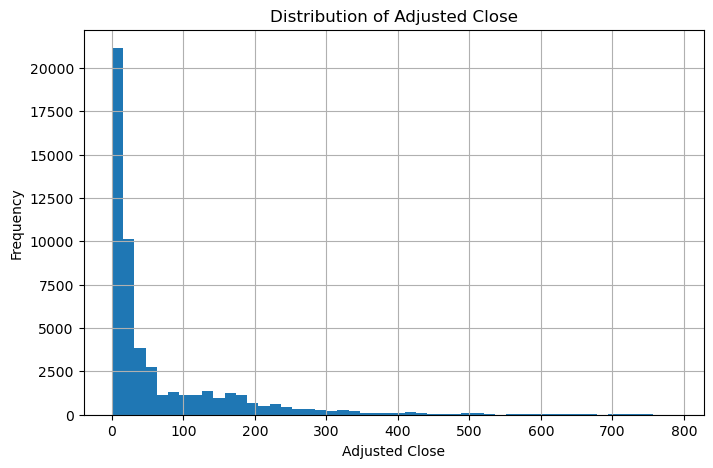

In [28]:
# Price distribution
import matplotlib.pyplot as plt

master["adj_close"].hist(bins=50, figsize=(8,5))
plt.title("Distribution of Adjusted Close")
plt.xlabel("Adjusted Close")
plt.ylabel("Frequency")
plt.show()

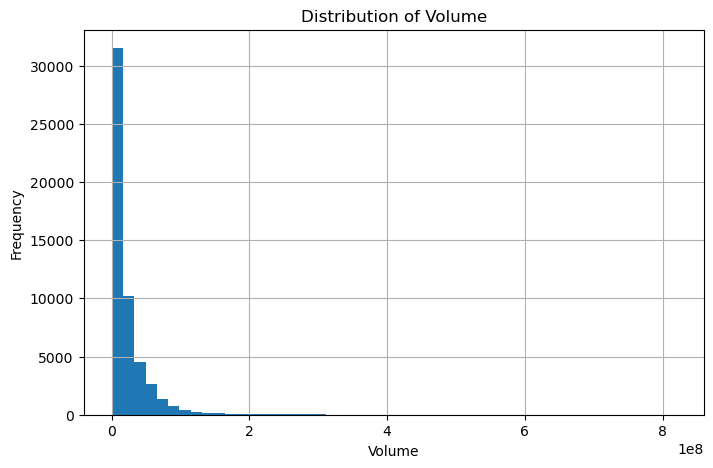

In [29]:
# Volume distribution
master["volume"].hist(bins=50, figsize=(8,5))
plt.title("Distribution of Volume")
plt.xlabel("Volume")
plt.ylabel("Frequency")
plt.show()

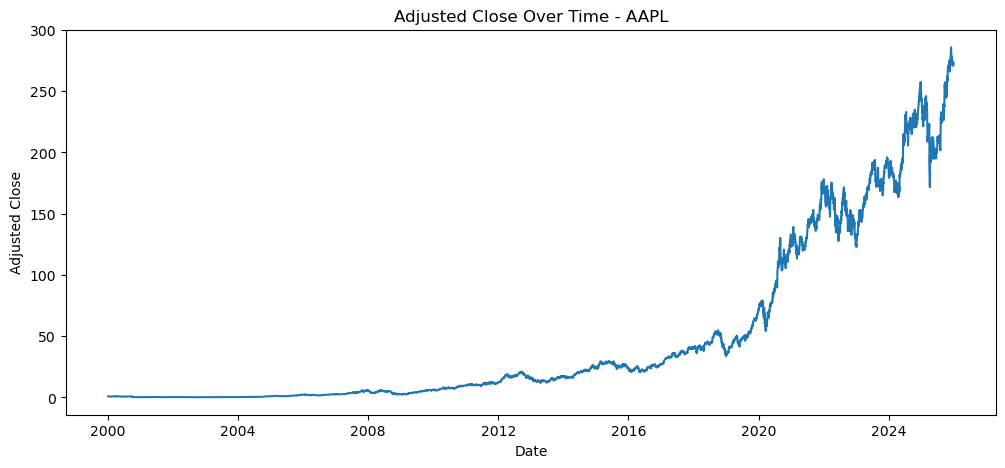

In [30]:
# One ticker price trand example
ticker_example = master[master["symbol"] == master["symbol"].unique()[0]]

plt.figure(figsize=(12,5))
plt.plot(ticker_example["date"], ticker_example["adj_close"])
plt.title(f"Adjusted Close Over Time - {ticker_example['symbol'].iloc[0]}")
plt.xlabel("Date")
plt.ylabel("Adjusted Close")
plt.show()

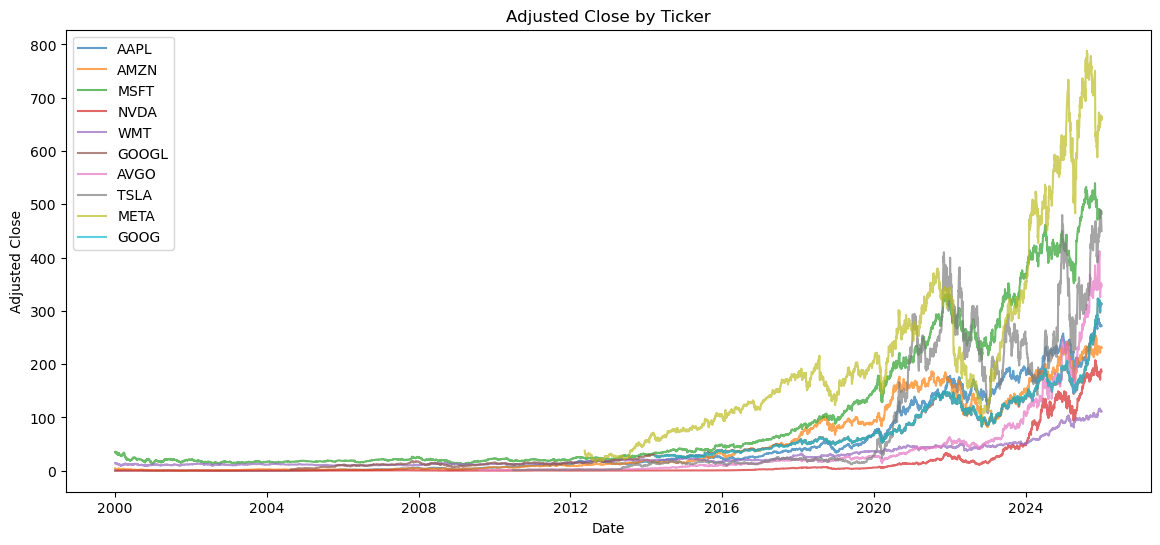

In [31]:
plt.figure(figsize=(14,6))
for sym in master["symbol"].unique():
    temp = master[master["symbol"] == sym]
    plt.plot(temp["date"], temp["adj_close"], label=sym, alpha=0.7)

plt.title("Adjusted Close by Ticker")
plt.xlabel("Date")
plt.ylabel("Adjusted Close")
plt.legend()
plt.show()

### Feature Engineering on Merged dataset

In [32]:
# Start feature engineering on merged master
master = master.sort_values(["symbol", "date"]).reset_index(drop=True)

master["return_1d"] = master.groupby("symbol")["adj_close"].pct_change()
master["log_return"] = master.groupby("symbol")["adj_close"].transform(
    lambda x: np.log(x / x.shift(1))
)

In [33]:
master[["symbol", "date", "adj_close", "return_1d", "log_return"]].head(10)

,symbol,date,adj_close,return_1d,log_return
0,AAPL,2000-01-03,0.8385,NaN,NaN
1,AAPL,2000-01-04,0.7678,-0.0843,-0.0881
2,AAPL,2000-01-05,0.7790,0.0146,0.0145
3,AAPL,2000-01-06,0.7116,-0.0865,-0.0905
4,AAPL,2000-01-07,0.7453,0.0474,0.0463
5,AAPL,2000-01-10,0.7322,-0.0176,-0.0177
6,AAPL,2000-01-11,0.6947,-0.0512,-0.0525
7,AAPL,2000-01-12,0.6531,-0.0599,-0.0618
8,AAPL,2000-01-13,0.7247,0.1096,0.1040
9,AAPL,2000-01-14,0.7523,0.0381,0.0374


In [34]:
# Momentum features
master["momentum_1m"] = master.groupby("symbol")["adj_close"].pct_change(21)
master["momentum_3m"] = master.groupby("symbol")["adj_close"].pct_change(63)
master["momentum_6m"] = master.groupby("symbol")["adj_close"].pct_change(126)

In [35]:
# Moving averages

master["ma_20"] = master.groupby("symbol")["adj_close"].transform(lambda x: x.rolling(20).mean())
master["ma_50"] = master.groupby("symbol")["adj_close"].transform(lambda x: x.rolling(50).mean())
master["ma_200"] = master.groupby("symbol")["adj_close"].transform(lambda x: x.rolling(200).mean())

master["price_vs_ma50"] = master["adj_close"] / master["ma_50"] - 1
master["price_vs_ma200"] = master["adj_close"] / master["ma_200"] - 1

In [36]:
# Volatility features
master["vol_20"] = master.groupby("symbol")["return_1d"].transform(
    lambda x: x.rolling(20).std() * np.sqrt(252)
)

master["vol_60"] = master.groupby("symbol")["return_1d"].transform(
    lambda x: x.rolling(60).std() * np.sqrt(252)
)

In [37]:
# Parkinson volatility

master["parkinson_daily"] = (np.log(master["high"] / master["low"])) ** 2

master["parkinson_vol_20"] = master.groupby("symbol")["parkinson_daily"].transform(
    lambda x: np.sqrt((1 / (4 * np.log(2))) * x.rolling(20).mean()) * np.sqrt(252)
)

In [38]:
# Intraday range
master["intraday_range"] = (master["high"] - master["low"]) / master["close"]

In [39]:
# Drawdown features
master["rolling_max"] = master.groupby("symbol")["adj_close"].transform(lambda x: x.cummax())
master["drawdown"] = master["adj_close"] / master["rolling_max"] - 1
master["drawdown_regime"] = np.where(master["drawdown"] < -0.20, 1, 0)

In [40]:
# Volume features
master["volume_change"] = master.groupby("symbol")["volume"].pct_change()

master["volume_ma20"] = master.groupby("symbol")["volume"].transform(
    lambda x: x.rolling(20).mean()
)

master["volume_spike"] = master["volume"] / master["volume_ma20"]

In [41]:
# Dividend feature
master["dividend_yield_daily"] = master["dividend"] / master["adj_close"]

### Create simple financial ratios

In [42]:
# Debt and equity features
master["debt_to_equity"] = master["totalLiabilities"] / master["totalShareholderEquity"]
master["asset_to_liability"] = master["totalAssets"] / master["totalLiabilities"]
master["cash_to_assets"] = master["cashAndCashEquivalentsAtCarryingValue"] / master["totalAssets"]

In [43]:
# Per-share / book features

master["book_value_per_share_proxy"] = master["totalShareholderEquity"] / master["commonStockSharesOutstanding"]
master["price_to_book_proxy"] = master["adj_close"] / master["book_value_per_share_proxy"]

In [44]:
# Margin proxies
master["gross_margin"] = master["grossProfit"] / master["totalRevenue"]
master["operating_margin_calc"] = master["operatingIncome"] / master["totalRevenue"]
master["net_margin_calc"] = master["netIncome"] / master["totalRevenue"]

In [45]:
# cashflow ratio
master["operating_cf_to_assets"] = master["operatingCashflow"] / master["totalAssets"]
master["capex_to_assets"] = master["capitalExpenditures"] / master["totalAssets"]


In [46]:
feature_cols_preview = [
    "return_1d", "log_return",
    "momentum_1m", "momentum_3m", "momentum_6m",
    "ma_20", "ma_50", "ma_200",
    "price_vs_ma50", "price_vs_ma200",
    "vol_20", "vol_60", "parkinson_vol_20",
    "intraday_range",
    "drawdown", "drawdown_regime",
    "volume_change", "volume_ma20", "volume_spike",
    "dividend_yield_daily",
    "debt_to_equity", "asset_to_liability", "cash_to_assets",
    "book_value_per_share_proxy", "price_to_book_proxy",
    "gross_margin", "operating_margin_calc", "net_margin_calc",
    "operating_cf_to_assets", "capex_to_assets"
]

master[["symbol", "date"] + feature_cols_preview].head(15)

,symbol,date,return_1d,log_return,momentum_1m,momentum_3m,momentum_6m,ma_20,ma_50,ma_200,price_vs_ma50,price_vs_ma200,vol_20,vol_60,parkinson_vol_20,intraday_range,drawdown,drawdown_regime,volume_change,volume_ma20,volume_spike,dividend_yield_daily,debt_to_equity,asset_to_liability,cash_to_assets,book_value_per_share_proxy,price_to_book_proxy,gross_margin,operating_margin_calc,net_margin_calc,operating_cf_to_assets,capex_to_assets
0,AAPL,2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0966,0.0000,0,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AAPL,2000-01-04,-0.0843,-0.0881,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0920,-0.0843,0,-0.0437,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AAPL,2000-01-05,0.0146,0.0145,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0727,-0.0709,0,0.5190,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AAPL,2000-01-06,-0.0865,-0.0905,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1263,-0.1513,0,-0.0133,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AAPL,2000-01-07,0.0474,0.0463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0553,-0.1111,0,-0.4001,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,AAPL,2000-01-10,-0.0176,-0.0177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0767,-0.1268,0,0.0962,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,AAPL,2000-01-11,-0.0512,-0.0525,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0956,-0.1714,0,-0.1258,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,AAPL,2000-01-12,-0.0599,-0.0618,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.1032,-0.2211,1,1.2106,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,AAPL,2000-01-13,0.1096,0.1040,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0646,-0.1357,0,0.0580,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,AAPL,2000-01-14,0.0381,0.0374,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0287,-0.1027,0,-0.6220,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
### Summary stats for features columns
master[feature_cols_preview].describe().T

,count,mean,std,min,25%,50%,75%,max
return_1d,52476.0000,0.0012,0.0260,-0.5187,-0.0097,0.0008,0.0119,0.4241
log_return,52476.0000,0.0008,0.0260,-0.7312,-0.0098,0.0008,0.0118,0.3535
momentum_1m,52276.0000,0.0246,0.1172,-0.6898,-0.0354,0.0204,0.0771,2.0315
momentum_3m,51856.0000,0.0753,0.2157,-0.7707,-0.0413,0.0576,0.1654,2.2046
momentum_6m,51226.0000,0.1567,0.3494,-0.8593,-0.0242,0.1125,0.2761,5.1148
ma_20,52296.0000,65.0443,99.6124,0.0657,8.5358,20.7507,83.4508,762.4668
ma_50,51996.0000,64.4240,98.2884,0.0735,8.6794,20.6850,82.5131,752.1692
ma_200,50496.0000,61.6071,91.6967,0.0922,8.9446,20.4431,77.7555,677.0059
price_vs_ma50,51996.0000,0.0233,0.0999,-0.6165,-0.0259,0.0233,0.0723,0.9725
price_vs_ma200,50496.0000,0.0968,0.2144,-0.8066,-0.0131,0.0859,0.1912,1.9828


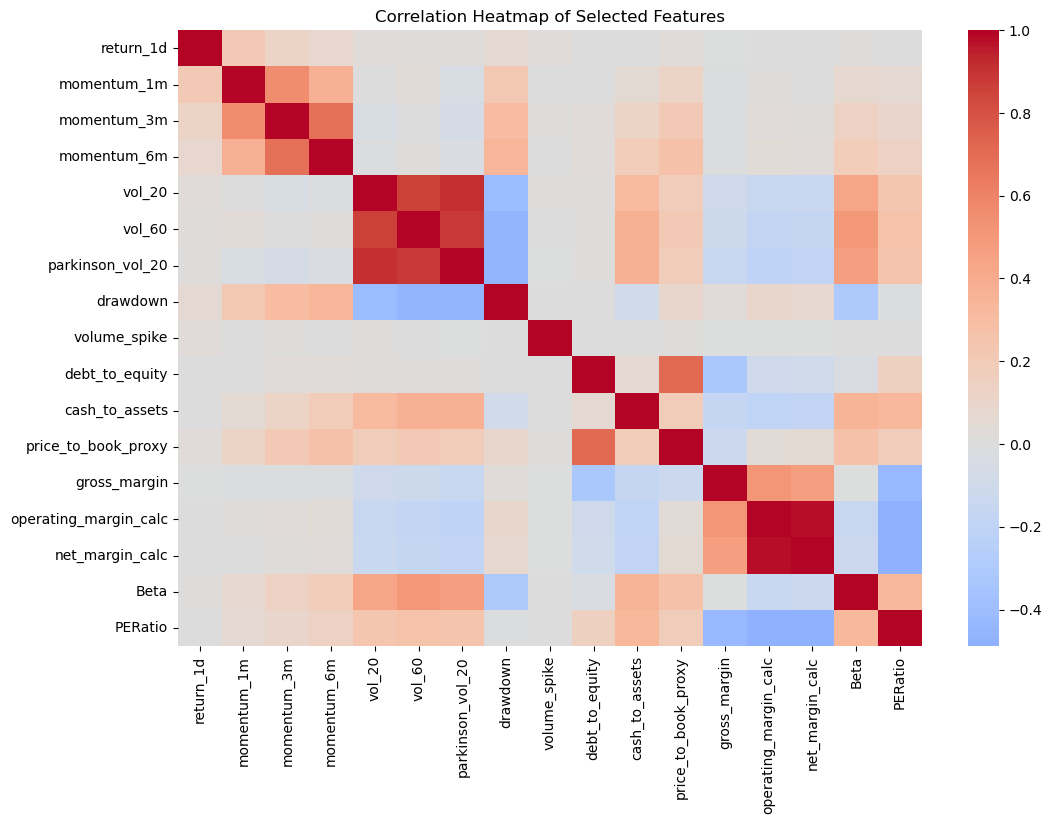

In [48]:
# Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = [
    "return_1d", "momentum_1m", "momentum_3m", "momentum_6m",
    "vol_20", "vol_60", "parkinson_vol_20",
    "drawdown", "volume_spike",
    "debt_to_equity", "cash_to_assets",
    "price_to_book_proxy", "gross_margin",
    "operating_margin_calc", "net_margin_calc",
    "Beta", "PERatio"
]

corr_df = master[corr_cols].copy()
corr = corr_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Selected Features")
plt.show()

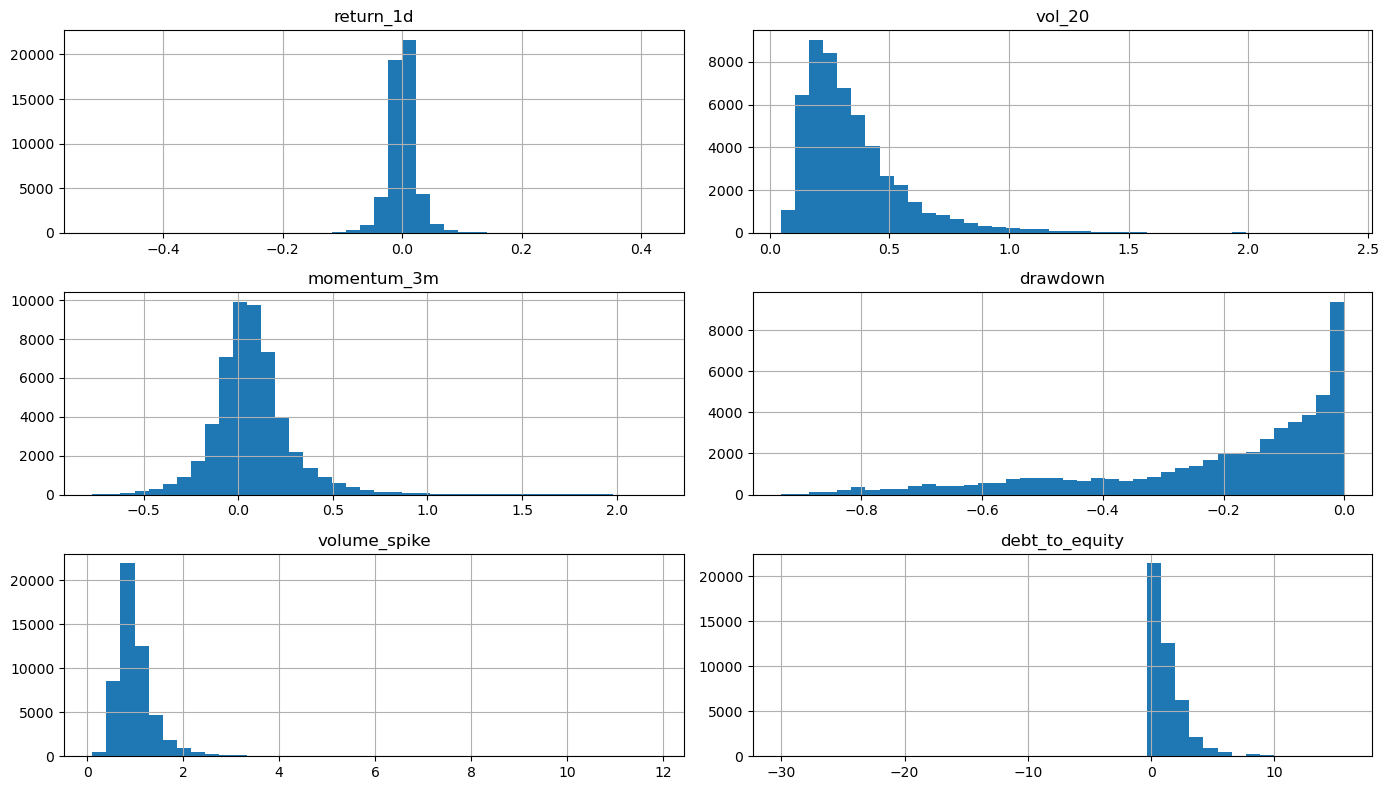

In [49]:
# Histograms of key features
key_hist_cols = ["return_1d", "vol_20", "momentum_3m", "drawdown", "volume_spike", "debt_to_equity"]

master[key_hist_cols].hist(bins=40, figsize=(14,8))
plt.tight_layout()
plt.show()

In [50]:
#handle infinite values cretaed by master
master = master.replace([np.inf, -np.inf], np.nan)

In [51]:
master[feature_cols_preview].isnull().sum().sort_values(ascending=False).head(20)

capex_to_assets               7924
book_value_per_share_proxy    7924
asset_to_liability            7924
debt_to_equity                7924
price_to_book_proxy           7924
gross_margin                  7924
operating_margin_calc         7924
net_margin_calc               7924
operating_cf_to_assets        7924
cash_to_assets                7924
price_vs_ma200                1990
ma_200                        1990
momentum_6m                   1260
momentum_3m                    630
vol_60                         600
price_vs_ma50                  490
ma_50                          490
momentum_1m                    210
vol_20                         200
parkinson_vol_20               190
dtype: int64

In [52]:
# Drop the null rows existing due to rolling features
master = master.dropna().reset_index(drop=True)

print("Final dataset shape:", master.shape)

Final dataset shape: (43766, 79)


In [53]:
# Saved merged and Engineered dataset
OUT_FEATURE_PATH = BASE / "master_price_fundamentals_features.parquet"
master.to_parquet(OUT_FEATURE_PATH, index=False)

print("Saved:", OUT_FEATURE_PATH)

Saved: ../data/clean/master_price_fundamentals_features.parquet


### prepare the option dataset

In [54]:
# =========================
# STEP 1: PREPARE OPTIONS
# =========================

options["trade_date"] = pd.to_datetime(options["trade_date"])
options["expiration"] = pd.to_datetime(options["expiration"])

# keep only call options
calls = options[options["call_put"].str.lower() == "call"].copy()

print("Calls shape:", calls.shape)
calls.head()

Calls shape: (1596099, 20)


,contractID,symbol,expiration,strike,call_put,last,mark,bid,bid_size,ask,ask_size,volume,open_interest,trade_date,implied_vol,delta,gamma,theta,vega,rho
0,AVGO090919C00015000,AVGO,2009-09-19,15.0000,call,0.0000,0.0100,2.5000,0,3.3000,0,0,0,2009-09-01,0.0149,1.0000,0.0000,-0.0001,0.0000,0.0074
2,AVGO090919C00017500,AVGO,2009-09-19,17.5000,call,1.2000,0.0100,0.8000,0,1.1000,0,0,20,2009-09-01,0.0149,1.0000,0.0000,-0.0001,0.0000,0.0086
4,AVGO090919C00020000,AVGO,2009-09-19,20.0000,call,0.2500,0.0100,0.1500,0,0.3000,0,0,8,2009-09-01,0.2588,0.0256,0.0582,-0.0017,0.0024,0.0002
6,AVGO091017C00015000,AVGO,2009-10-17,15.0000,call,0.0000,0.0100,2.7500,0,3.5000,0,0,0,2009-09-01,0.0149,1.0000,0.0000,-0.0001,0.0000,0.0189
8,AVGO091017C00017500,AVGO,2009-10-17,17.5000,call,1.0000,0.0100,1.2000,0,1.5500,0,0,5,2009-09-01,0.0149,0.9999,0.0032,-0.0001,0.0000,0.0221


In [55]:
# Merge daily stock prices into options
price_lookup = master[["symbol", "date", "adj_close"]].rename(
    columns={"date": "trade_date", "adj_close": "stock_price"}
)

calls = calls.merge(
    price_lookup,
    on=["symbol", "trade_date"],
    how="inner"
)

print("Calls after merging stock price:", calls.shape)
calls.head()

Calls after merging stock price: (1553357, 21)


,contractID,symbol,expiration,strike,call_put,last,mark,bid,bid_size,ask,ask_size,volume,open_interest,trade_date,implied_vol,delta,gamma,theta,vega,rho,stock_price
0,AVGO100619C00017500,AVGO,2010-06-19,17.5000,call,1.7500,3.1000,2.8000,38,3.4000,92,0,0,2010-06-01,0.6588,0.8683,0.0715,-0.0178,0.0097,0.0072,1.4567
1,AVGO100619C00020000,AVGO,2010-06-19,20.0000,call,0.5800,1.0200,0.8500,33,1.2000,74,0,89,2010-06-01,0.4539,0.5960,0.1885,-0.0222,0.0175,0.0055,1.4567
2,AVGO100619C00022500,AVGO,2010-06-19,22.5000,call,0.1500,0.2000,0.0500,14,0.3500,80,0,78,2010-06-01,0.4637,0.1830,0.1263,-0.0155,0.0120,0.0017,1.4567
3,AVGO100619C00025000,AVGO,2010-06-19,25.0000,call,0.1500,0.0100,0.0000,0,0.1500,57,0,10,2010-06-01,0.4149,0.0152,0.0204,-0.0020,0.0017,0.0001,1.4567
4,AVGO100619C00030000,AVGO,2010-06-19,30.0000,call,0.0800,0.0100,0.0000,0,0.1500,57,0,20,2010-06-01,0.7173,0.0095,0.0079,-0.0023,0.0012,0.0001,1.4567


In [56]:
# compute dte


calls["dte"] = (calls["expiration"] - calls["trade_date"]).dt.days
calls = calls[calls["dte"] > 0].copy()

print(calls["dte"].describe())

count   1534298.0000
mean        174.9382
std         214.4115
min           1.0000
25%          23.0000
50%          78.0000
75%         234.0000
max        1052.0000
Name: dte, dtype: float64


In [57]:
# Filter to reasnable delta range


calls_filtered = calls[(calls["delta"] >= 0.10) & (calls["delta"] <= 0.70)].copy()

print(f"Contracts in delta range 0.10-0.70: {len(calls_filtered):,}")
print(calls_filtered["delta"].describe())

Contracts in delta range 0.10-0.70: 450,031
count   450031.0000
mean         0.3931
std          0.1801
min          0.1000
25%          0.2306
50%          0.3915
75%          0.5534
max          0.7000
Name: delta, dtype: float64


In [58]:

# ASSIGN MONEyness BUCKET


def assign_moneyness_bucket(delta):
    if 0.10 <= delta < 0.28:
        return "OTM10"
    elif 0.29 <= delta < 0.60:
        return "OTM5"
    elif 0.61 <= delta <= 0.70:
        return "ATM"
    else:
        return "OUT_OF_RANGE"

calls_filtered["moneyness_bucket"] = calls_filtered["delta"].apply(assign_moneyness_bucket)

print(calls_filtered["moneyness_bucket"].value_counts(dropna=False))

calls_filtered = calls_filtered[
    calls_filtered["moneyness_bucket"] != "OUT_OF_RANGE"
].copy()

moneyness_bucket
OTM5            216624
OTM10           148551
ATM              70328
OUT_OF_RANGE     14528
Name: count, dtype: int64


In [59]:
# assign DTE bucket

def assign_dte_bucket(dte):
    if 7 <= dte <= 30:
        return "30"
    elif 31 <= dte <= 60:
        return "60"
    elif 61 <= dte <= 120:
        return "90"
    else:
        return "OUT_OF_RANGE"

calls_filtered["dte_bucket"] = calls_filtered["dte"].apply(assign_dte_bucket)

print(calls_filtered["dte_bucket"].value_counts(dropna=False))

calls_filtered = calls_filtered[
    calls_filtered["dte_bucket"] != "OUT_OF_RANGE"
].copy()

dte_bucket
OUT_OF_RANGE    250004
30               73786
60               68410
90               43303
Name: count, dtype: int64


In [60]:
# Build final contract bucket label
calls_filtered["bucket_label"] = (
    calls_filtered["moneyness_bucket"] + "_" + calls_filtered["dte_bucket"]
)

print(calls_filtered["bucket_label"].value_counts())
calls_filtered[["symbol", "trade_date", "delta", "dte", "bucket_label"]].head()

bucket_label
OTM5_30     34987
OTM5_60     34036
OTM10_30    27298
OTM10_60    23297
OTM5_90     20289
OTM10_90    16321
ATM_30      11501
ATM_60      11077
ATM_90       6693
Name: count, dtype: int64


,symbol,trade_date,delta,dte,bucket_label
1,AVGO,2010-06-01,0.5960,18,OTM5_30
2,AVGO,2010-06-01,0.1830,18,OTM10_30
8,AVGO,2010-06-01,0.5808,46,OTM5_60
10,AVGO,2010-06-01,0.1069,46,OTM10_60
25,AVGO,2010-07-01,0.3177,16,OTM5_30


In [61]:
# compute premium


calls_filtered["premium"] = (calls_filtered["bid"] + calls_filtered["ask"]) / 2

calls_filtered[["bid", "ask", "premium"]].head()

,bid,ask,premium
1,0.8500,1.2000,1.0250
2,0.0500,0.3500,0.2000
8,1.3000,1.6000,1.4500
10,0.0500,0.2500,0.1500
25,0.3000,0.5000,0.4000


In [62]:
# clean numeric options

numeric_cols = [
    "strike", "bid", "ask", "last", "volume", "open_interest",
    "implied_vol", "delta", "gamma", "theta", "vega", "rho"
]

for col in numeric_cols:
    if col in calls.columns:
        calls[col] = pd.to_numeric(calls[col], errors="coerce")

In [63]:
# get future stock price at expiration

future_prices = master[["symbol", "date", "adj_close"]].rename(
    columns={"date": "expiration", "adj_close": "future_price"}
)

calls_filtered = calls_filtered.merge(
    future_prices,
    on=["symbol", "expiration"],
    how="left"
)

calls_filtered = calls_filtered.dropna(subset=["future_price"]).copy()

print("After merging future price:", calls_filtered.shape)

After merging future price: (175309, 27)


In [64]:
# Compute covered call payoff and return

calls_filtered["covered_call_payoff"] = (
    calls_filtered["premium"] +
    np.minimum(calls_filtered["future_price"], calls_filtered["strike"]) -
    calls_filtered["stock_price"]
)

calls_filtered["covered_call_return"] = (
    calls_filtered["covered_call_payoff"] / calls_filtered["stock_price"]
)

calls_filtered[[
    "symbol", "trade_date", "bucket_label",
    "stock_price", "strike", "premium", "future_price",
    "covered_call_payoff", "covered_call_return"
]].head()

,symbol,trade_date,bucket_label,stock_price,strike,premium,future_price,covered_call_payoff,covered_call_return
329,AVGO,2015-02-02,ATM_30,7.8439,100.0000,4.8000,8.5822,5.5383,0.7061
330,AVGO,2015-02-02,OTM5_30,7.8439,105.0000,2.1500,8.5822,2.8883,0.3682
331,AVGO,2015-02-02,OTM10_30,7.8439,110.0000,0.9000,8.5822,1.6383,0.2089
332,AVGO,2015-02-02,ATM_60,7.8439,97.5000,8.3000,10.2379,10.6939,1.3633
333,AVGO,2015-02-02,OTM5_60,7.8439,100.0000,7.1000,10.2379,9.4939,1.2104


In [65]:

# COMPUTE REALIZED VOLATILITY OVER HOLDING PERIOD


price_lookup = master[["symbol", "date", "return_1d"]].copy()
price_lookup = price_lookup.sort_values(["symbol", "date"]).reset_index(drop=True)

def realized_vol_for_cycle(symbol, start_date, end_date, price_df):
    temp = price_df[
        (price_df["symbol"] == symbol) &
        (price_df["date"] >= start_date) &
        (price_df["date"] <= end_date)
    ].copy()

    if temp["return_1d"].dropna().shape[0] < 2:
        return np.nan

    return temp["return_1d"].std() * np.sqrt(252)

calls_filtered["realized_vol_cycle"] = calls_filtered.apply(
    lambda r: realized_vol_for_cycle(
        r["symbol"],
        r["trade_date"],
        r["expiration"],
        price_lookup
    ),
    axis=1
)

calls_filtered[[
    "symbol", "trade_date", "expiration",
    "covered_call_return", "realized_vol_cycle"
]].head()

,symbol,trade_date,expiration,covered_call_return,realized_vol_cycle
329,AVGO,2015-02-02,2015-02-20,0.7061,0.2622
330,AVGO,2015-02-02,2015-02-20,0.3682,0.2622
331,AVGO,2015-02-02,2015-02-20,0.2089,0.2622
332,AVGO,2015-02-02,2015-03-20,1.3633,0.4537
333,AVGO,2015-02-02,2015-03-20,1.2104,0.4537


In [66]:
# Compute risk-free cycle return and Sharpe proxy

RISK_FREE = 0.05

calls_filtered["rf_cycle"] = (
    (1 + RISK_FREE) ** (calls_filtered["dte"] / 252) - 1
)

calls_filtered["sharpe_proxy"] = (
    (calls_filtered["covered_call_return"] - calls_filtered["rf_cycle"]) /
    calls_filtered["realized_vol_cycle"]
)

calls_filtered = calls_filtered.replace([np.inf, -np.inf], np.nan)

calls_filtered[[
    "symbol", "bucket_label", "covered_call_return",
    "realized_vol_cycle", "rf_cycle", "sharpe_proxy"
]].head()

,symbol,bucket_label,covered_call_return,realized_vol_cycle,rf_cycle,sharpe_proxy
329,AVGO,ATM_30,0.7061,0.2622,0.0035,2.6794
330,AVGO,OTM5_30,0.3682,0.2622,0.0035,1.3909
331,AVGO,OTM10_30,0.2089,0.2622,0.0035,0.7832
332,AVGO,ATM_60,1.3633,0.4537,0.0089,2.9855
333,AVGO,OTM5_60,1.2104,0.4537,0.0089,2.6483


In [67]:
# Aggregate sharpe to bucket level


bucket_perf = (
    calls_filtered
    .dropna(subset=["sharpe_proxy"])
    .groupby(["symbol", "trade_date", "bucket_label"], as_index=False)
    .agg({
        "covered_call_return": "mean",
        "realized_vol_cycle": "mean",
        "rf_cycle": "mean",
        "sharpe_proxy": "mean"
    })
)

print(bucket_perf.shape)
bucket_perf.head()

(10360, 7)


,symbol,trade_date,bucket_label,covered_call_return,realized_vol_cycle,rf_cycle,sharpe_proxy
0,AAPL,2010-07-01,OTM10_30,0.2900,0.2948,0.0016,0.9783
1,AAPL,2010-07-01,OTM5_30,0.6963,0.2948,0.0016,2.3566
2,AAPL,2010-10-01,OTM10_30,0.2145,0.2868,0.0014,0.7433
3,AAPL,2010-10-01,OTM5_30,0.7320,0.2868,0.0014,2.5474
4,AAPL,2011-04-01,ATM_30,0.6529,0.0709,0.0014,9.1882


In [68]:
# create label df

label_df = (
    bucket_perf
    .sort_values(
        ["symbol", "trade_date", "sharpe_proxy"],
        ascending=[True, True, False]
    )
    .groupby(["symbol", "trade_date"], as_index=False)
    .first()
)

label_df = label_df.rename(
    columns={
        "trade_date": "date",
        "bucket_label": "optimal_bucket"
    }
)

print(label_df.shape)
print(label_df["optimal_bucket"].value_counts())
label_df.head()

(1243, 7)
optimal_bucket
ATM_90      620
ATM_60      179
OTM10_90    158
ATM_30      112
OTM5_90      65
OTM10_60     39
OTM10_30     29
OTM5_30      26
OTM5_60      15
Name: count, dtype: int64


,symbol,date,optimal_bucket,covered_call_return,realized_vol_cycle,rf_cycle,sharpe_proxy
0,AAPL,2010-07-01,OTM5_30,0.6963,0.2948,0.0016,2.3566
1,AAPL,2010-10-01,OTM5_30,0.7320,0.2868,0.0014,2.5474
2,AAPL,2011-04-01,ATM_30,0.6529,0.0709,0.0014,9.1882
3,AAPL,2011-07-01,ATM_30,0.5414,0.1107,0.0014,4.8787
4,AAPL,2011-09-01,ATM_30,0.8754,0.2277,0.0016,3.8378


In [ ]:
# Merge label df into master

# Merge label_df into master using LEFT JOIN
final_dataset = master.merge(
    label_df[["symbol", "date", "optimal_bucket"]],
    on=["symbol", "date"],
    how="left"
)

# Sort before fill
final_dataset = final_dataset.sort_values(["symbol", "date"]).reset_index(drop=True)

# Forward fill + backward fill within each symbol
# final_dataset["optimal_bucket"] = (
#     final_dataset.groupby("symbol")["optimal_bucket"]
#     .transform(lambda x: x.ffill().bfill())
# )

print("Final dataset shape:", final_dataset.shape)
print("Duplicate symbol-date rows:",
      final_dataset.duplicated(subset=["symbol", "date"]).sum())

print("Remaining missing optimal_bucket values:",
      final_dataset["optimal_bucket"].isna().sum())

final_dataset.tail()

Final dataset shape: (43766, 80)
Duplicate symbol-date rows: 0
Remaining missing optimal_bucket values: 0


,date,symbol,open,high,low,close,adj_close,volume,dividend,split_coeff,fiscalDateEnding,totalRevenue,grossProfit,operatingIncome,operatingExpenses,ebit,ebitda,totalAssets,totalCurrentAssets,cashAndCashEquivalentsAtCarryingValue,totalLiabilities,totalCurrentLiabilities,longTermDebt,totalShareholderEquity,commonStockSharesOutstanding,operatingCashflow,capitalExpenditures,cashflowFromInvestment,cashflowFromFinancing,dividendPayout,netIncome,MarketCapitalization,PERatio,BookValue,DividendYield,EPS,RevenueTTM,ProfitMargin,OperatingMarginTTM,ReturnOnAssetsTTM,ReturnOnEquityTTM,Beta,52WeekHigh,52WeekLow,50DayMovingAverage,200DayMovingAverage,SharesOutstanding,return_1d,log_return,momentum_1m,momentum_3m,momentum_6m,ma_20,ma_50,ma_200,price_vs_ma50,price_vs_ma200,vol_20,vol_60,parkinson_daily,parkinson_vol_20,intraday_range,rolling_max,drawdown,drawdown_regime,volume_change,volume_ma20,volume_spike,dividend_yield_daily,debt_to_equity,asset_to_liability,cash_to_assets,book_value_per_share_proxy,price_to_book_proxy,gross_margin,operating_margin_calc,net_margin_calc,operating_cf_to_assets,capex_to_assets,optimal_bucket
43761,2025-12-24,WMT,110.9000,111.7100,110.5500,111.6100,111.6100,9009629,0.0000,1.0000,2025-10-31,179496000000.0000,44790000000.0000,6696000000.0000,38094000000.0000,8870000000.0000,12476000000.0000,288655000000.0000,92920000000.0000,10582000000.0000,186143000000.0000,115732000000.0000,34445000000.0000,96094000000.0000,8011000000.0000,9100000000.0000,7218000000.0000,-7831000000.0000,-19000000.0000,1875000000.0000,6143000000.0000,965378245000,44.5200,12.5000,0.0077,2.7200,713163014000,0.0307,0.0457,0.0683,0.2180,0.6570,134.4100,79.1100,123.3000,107.8600,7972403000,0.0064,0.0064,0.0747,0.0852,0.1674,113.5799,107.7572,99.1607,0.0358,0.1255,0.1944,0.2402,0.0001,0.1765,0.0104,116.7900,-0.0444,0,-0.5566,21133910.1000,0.4263,0.0000,1.9371,1.5507,0.0367,11.9953,9.3045,0.2495,0.0373,0.0342,0.0315,0.0250,OTM10_30
43762,2025-12-26,WMT,111.7200,111.9700,111.3600,111.7400,111.7400,9003791,0.0000,1.0000,2025-10-31,179496000000.0000,44790000000.0000,6696000000.0000,38094000000.0000,8870000000.0000,12476000000.0000,288655000000.0000,92920000000.0000,10582000000.0000,186143000000.0000,115732000000.0000,34445000000.0000,96094000000.0000,8011000000.0000,9100000000.0000,7218000000.0000,-7831000000.0000,-19000000.0000,1875000000.0000,6143000000.0000,965378245000,44.5200,12.5000,0.0077,2.7200,713163014000,0.0307,0.0457,0.0683,0.2180,0.6570,134.4100,79.1100,123.3000,107.8600,7972403000,0.0012,0.0012,0.0464,0.0854,0.1538,113.7228,107.8158,99.2975,0.0364,0.1253,0.1832,0.2389,0.0000,0.1703,0.0055,116.7900,-0.0432,0,-0.0006,20694935.6000,0.4351,0.0000,1.9371,1.5507,0.0367,11.9953,9.3153,0.2495,0.0373,0.0342,0.0315,0.0250,OTM10_30
43763,2025-12-29,WMT,111.5900,112.7800,111.5700,112.5300,112.5300,12979573,0.0000,1.0000,2025-10-31,179496000000.0000,44790000000.0000,6696000000.0000,38094000000.0000,8870000000.0000,12476000000.0000,288655000000.0000,92920000000.0000,10582000000.0000,186143000000.0000,115732000000.0000,34445000000.0000,96094000000.0000,8011000000.0000,9100000000.0000,7218000000.0000,-7831000000.0000,-19000000.0000,1875000000.0000,6143000000.0000,965378245000,44.5200,12.5000,0.0077,2.7200,713163014000,0.0307,0.0457,0.0683,0.2180,0.6570,134.4100,79.1100,123.3000,107.8600,7972403000,0.0071,0.0070,0.0335,0.0939,0.1559,113.8349,107.9413,99.4416,0.0425,0.1316,0.1795,0.2389,0.0001,0.1687,0.0108,116.7900,-0.0365,0,0.4416,20851588.0000,0.6225,0.0000,1.9371,1.5507,0.0367,11.9953,9.3812,0.2495,0.0373,0.0342,0.0315,0.0250,OTM10_30
43764,2025-12-30,WMT,111.8900,112.6900,111.8350,111.9200,111.9200,11730590,0.0000,1.0000,2025-10-31,179496000000.0000,44790000000.0000,6696000000.0000,38094000000.0000,8870000000.0000,12476000000.0000,288655000000.0000,92920000000.0000,10582000000.0000,186143000000.0000,115732000000.0000,34445000000.0000,96094000000.0000,8011000000.0000,9100000000.0000,7218000000.0000,-7831000000.0000,-19000000.0000,1875000000.0000,6143000

In [70]:

# SAVE FINAL MODELING FILE

FINAL_MODEL_PATH = BASE / "daily_stock_optimal_bucket_modeling.parquet"
final_dataset.to_parquet(FINAL_MODEL_PATH, index=False)

print("Saved final modeling dataset:", FINAL_MODEL_PATH)

Saved final modeling dataset: ../data/clean/daily_stock_optimal_bucket_modeling.parquet


In [71]:
symbol_stats = (
    final_dataset.groupby("symbol")["date"]
    .agg(["min","max","count"])
)

print(symbol_stats)

              min        max  count
symbol                             
AAPL   2006-01-03 2025-12-31   5031
AMZN   2006-01-03 2025-12-31   5031
AVGO   2010-05-21 2025-12-31   3928
GOOG   2015-01-09 2025-12-31   2761
GOOGL  2006-01-03 2025-12-31   5031
META   2013-03-07 2025-12-31   3226
MSFT   2006-01-03 2025-12-31   5031
NVDA   2006-01-31 2025-12-31   5012
TSLA   2011-04-12 2025-12-31   3703
WMT    2006-01-31 2025-12-31   5012


In [72]:
bucket_counts = final_dataset["optimal_bucket"].value_counts()

print(bucket_counts)

optimal_bucket
ATM_90      15492
ATM_60       6588
ATM_30       5205
OTM5_30      3855
OTM10_30     3688
OTM10_90     3656
OTM5_60      2725
OTM5_90      1600
OTM10_60      957
Name: count, dtype: int64


In [73]:
bucket_pct = final_dataset["optimal_bucket"].value_counts(normalize=True)

print(bucket_pct.round(3))

optimal_bucket
ATM_90     0.3540
ATM_60     0.1510
ATM_30     0.1190
OTM5_30    0.0880
OTM10_30   0.0840
OTM10_90   0.0840
OTM5_60    0.0620
OTM5_90    0.0370
OTM10_60   0.0220
Name: proportion, dtype: float64


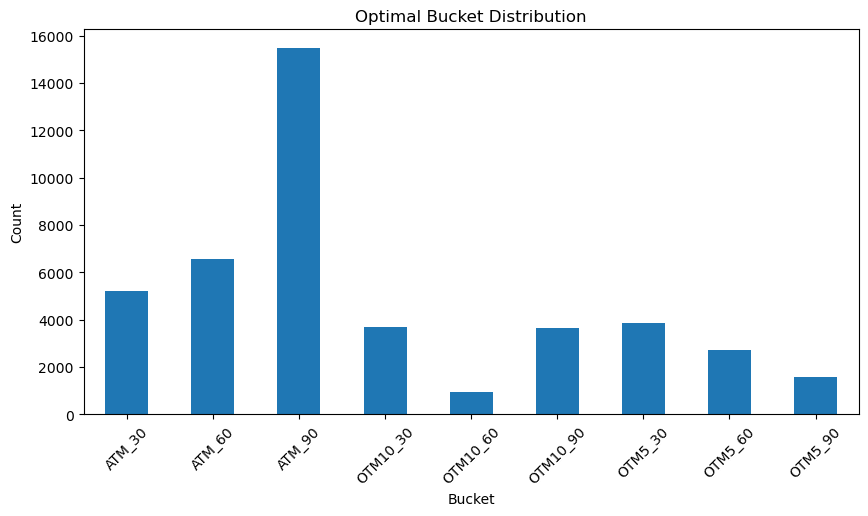

In [74]:
import matplotlib.pyplot as plt

final_dataset["optimal_bucket"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Optimal Bucket Distribution")
plt.xlabel("Bucket")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [75]:
# knowing important features from the final dataset

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

df = final_dataset.copy()

# Encode target
le = LabelEncoder()
df["optimal_bucket_encoded"] = le.fit_transform(df["optimal_bucket"])

# Drop non-feature columns
drop_cols = [
    "symbol",
    "date",
    "fiscalDateEnding",   # datetime column causing the issue
    "optimal_bucket",
    "optimal_bucket_encoded"
]

# keep only remaining columns
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df["optimal_bucket_encoded"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (43766, 76)
Target shape: (43766,)


In [76]:
# extra safety: keep only numeric columns
X = X.select_dtypes(include=["number"]).copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nNon-numeric columns still in X:")
print(X.select_dtypes(exclude=["number"]).columns.tolist())

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    n_jobs=-1,
    random_state=42
)

rf.fit(X, y)
print("Random Forest fitted successfully.")

X shape: (43766, 76)
y shape: (43766,)

Non-numeric columns still in X:
[]
Random Forest fitted successfully.


longTermDebt                            0.0468
ma_200                                  0.0426
ma_50                                   0.0362
rolling_max                             0.0346
ma_20                                   0.0315
high                                    0.0304
close                                   0.0293
volume_ma20                             0.0285
open                                    0.0276
adj_close                               0.0266
gross_margin                            0.0257
book_value_per_share_proxy              0.0256
low                                     0.0248
commonStockSharesOutstanding            0.0246
asset_to_liability                      0.0233
totalShareholderEquity                  0.0199
debt_to_equity                          0.0198
EPS                                     0.0193
totalCurrentAssets                      0.0190
totalAssets                             0.0188
totalLiabilities                        0.0181
SharesOutstan

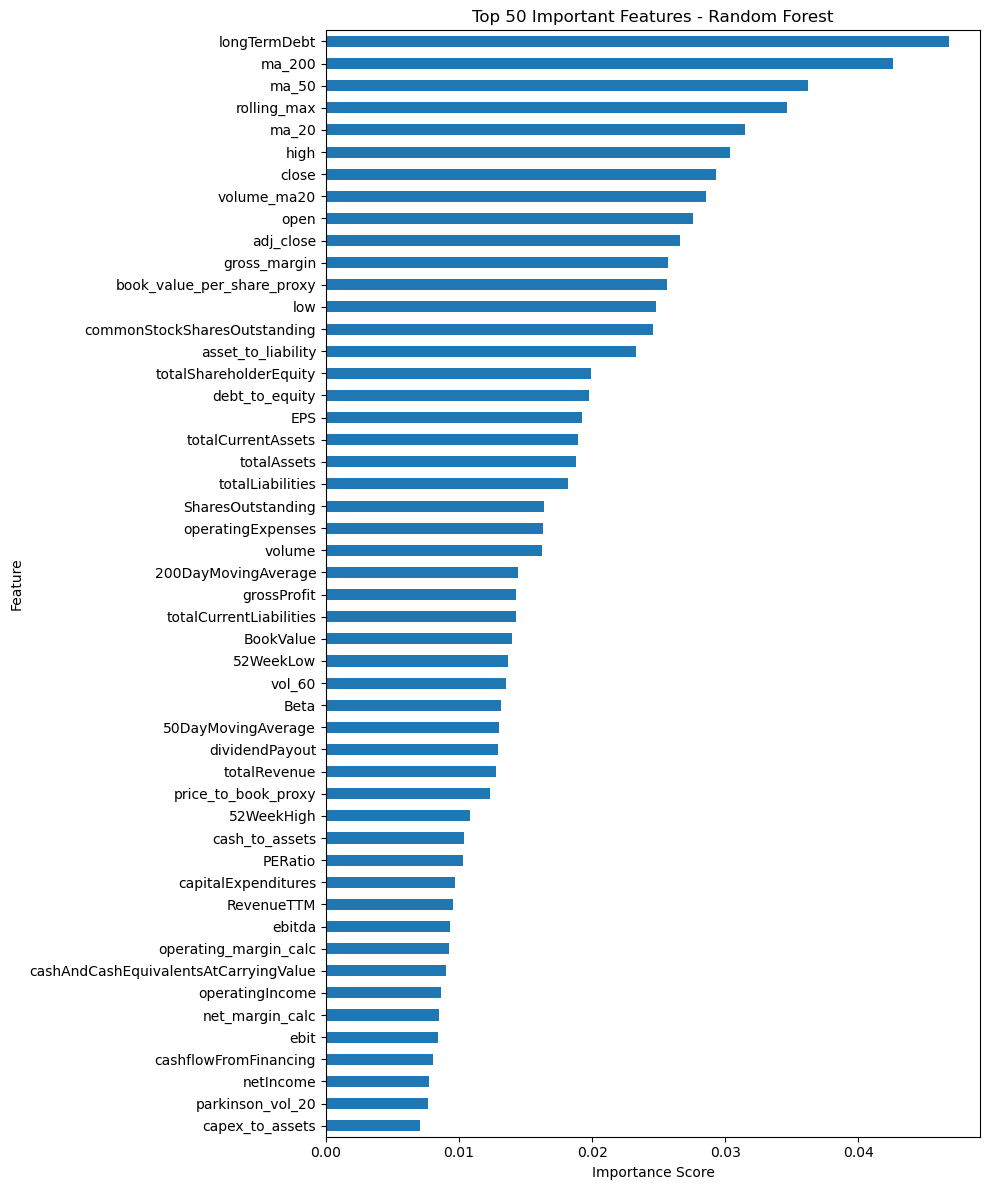

In [77]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_50_features = feature_importance.head(50)

print(top_50_features)

plt.figure(figsize=(10, 12))
top_50_features.sort_values().plot(kind="barh")
plt.title("Top 50 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [78]:
print(df.select_dtypes(exclude=["number"]).columns.tolist())

['date', 'symbol', 'fiscalDateEnding', 'optimal_bucket']


### Merge final file with FRED data

In [79]:
import pandas as pd
from pathlib import Path

# -----------------------------
# Paths
# -----------------------------
MAIN_PATH = Path("../data/clean/daily_stock_optimal_bucket_modeling.parquet")
FRED_PATH = Path("../data/clean/fred/fred_features_daily.parquet")

# -----------------------------
# Load datasets
# -----------------------------
main_df = pd.read_parquet(MAIN_PATH)
fred_df = pd.read_parquet(FRED_PATH)

main_df["date"] = pd.to_datetime(main_df["date"])
fred_df["date"] = pd.to_datetime(fred_df["date"])

print("Main shape before merge:", main_df.shape)
print("FRED shape:", fred_df.shape)

Main shape before merge: (43766, 80)
FRED shape: (7289, 9)


In [80]:
# -----------------------------
# Merge on date
# -----------------------------
merged_df = main_df.merge(
    fred_df,
    on="date",
    how="left"
)

print("Merged shape:", merged_df.shape)
print("\nTop null counts after merge:")
print(merged_df.isnull().sum().sort_values(ascending=False).head(20))

Merged shape: (43766, 88)

Top null counts after merge:
NFCI                2500
UNRATE              2500
inflation_yoy       2500
CPIAUCSL            2500
yield_curve         2500
DGS2                2500
DGS10               2500
FEDFUNDS            2500
ma_50                  0
parkinson_vol_20       0
parkinson_daily        0
vol_60                 0
vol_20                 0
price_vs_ma200         0
price_vs_ma50          0
ma_200                 0
momentum_1m            0
ma_20                  0
momentum_6m            0
momentum_3m            0
dtype: int64


In [81]:
# -----------------------------
# Optional: drop rows if macro is missing
# -----------------------------
macro_anchor_cols = ["FEDFUNDS", "yield_curve", "inflation_yoy", "UNRATE", "NFCI"]

merged_df = merged_df.dropna(subset=[c for c in macro_anchor_cols if c in merged_df.columns]).reset_index(drop=True)

print("Shape after dropping macro-missing rows:", merged_df.shape)

Shape after dropping macro-missing rows: (41266, 88)


In [82]:
# -----------------------------
# Save enriched modeling file
# -----------------------------
OUT_PATH = Path("../data/clean/daily_stock_optimal_bucket_modeling_with_fred.parquet")
merged_df.to_parquet(OUT_PATH, index=False)

print("Saved merged dataset at:", OUT_PATH)

Saved merged dataset at: ../data/clean/daily_stock_optimal_bucket_modeling_with_fred.parquet


In [83]:
print(merged_df[["date", "FEDFUNDS", "yield_curve", "inflation_yoy", "UNRATE", "NFCI"]].head())
print(merged_df[["date", "FEDFUNDS", "yield_curve", "inflation_yoy", "UNRATE", "NFCI"]].tail())

        date  FEDFUNDS  yield_curve  inflation_yoy  UNRATE    NFCI
0 2006-01-03    4.2900       0.0300         0.0061  4.7000 -0.5649
1 2006-01-04    4.2900       0.0500         0.0061  4.7000 -0.5649
2 2006-01-05    4.2900       0.0400         0.0061  4.7000 -0.5649
3 2006-01-06    4.2900       0.0200         0.0061  4.7000 -0.5712
4 2006-01-09    4.2900       0.0200         0.0061  4.7000 -0.5712
            date  FEDFUNDS  yield_curve  inflation_yoy  UNRATE    NFCI
41261 2024-12-24    4.4800       0.3000         0.0000  4.1000 -0.4814
41262 2024-12-26    4.4800       0.2800         0.0000  4.1000 -0.4814
41263 2024-12-27    4.4800       0.3100         0.0000  4.1000 -0.4855
41264 2024-12-30    4.4800       0.3100         0.0000  4.1000 -0.4855
41265 2024-12-31    4.4800       0.3300         0.0000  4.1000 -0.4855
